In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [53]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [54]:
sns.set_style("whitegrid")

In [55]:
df=pd.read_csv("C:\\Users\\janaj\\Downloads\\credit score\\german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [56]:
df['Risk'].value_counts()


Risk
good    700
bad     300
Name: count, dtype: int64

In [57]:
df.isna().sum()


Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [58]:
df=df.dropna().reset_index(drop=True)
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
5,10,25,female,2,rent,little,moderate,1295,12,car,bad
6,11,24,female,2,rent,little,little,4308,48,business,bad
7,12,22,female,2,own,little,moderate,1567,12,radio/TV,good
8,13,60,male,1,own,little,little,1199,24,car,bad
9,14,28,female,2,rent,little,little,1403,15,car,good


In [59]:
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [60]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [61]:
df.drop(columns='Unnamed: 0',inplace=True)

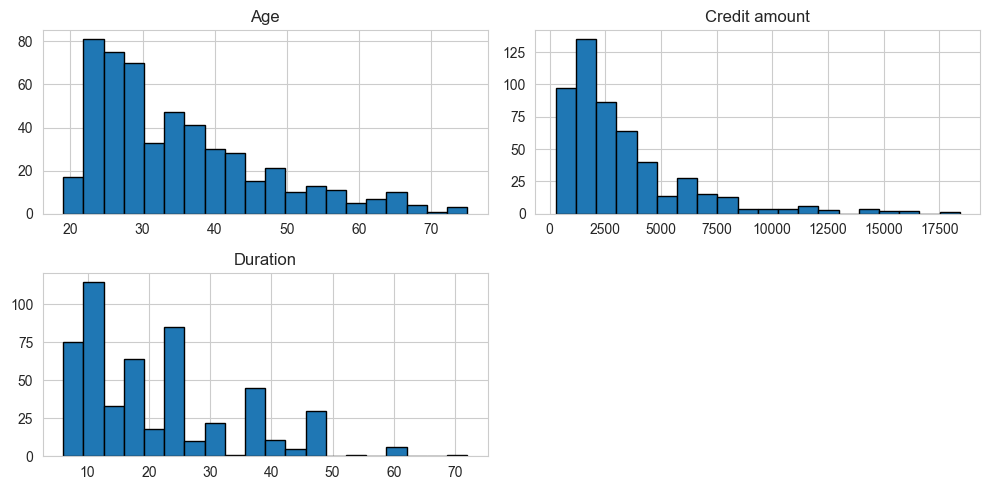

In [62]:
df[['Age','Credit amount', 'Duration']].hist(bins=20,edgecolor='black',figsize=(10,5))
plt.tight_layout()
plt.show()

In [63]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [64]:
cat_cols=['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Purpose']

C:\Users\janaj\AppData\Local\Temp\ipykernel_744\3483568567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\janaj\AppData\Local\Temp\ipykernel_744\3483568567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\janaj\AppData\Local\Temp\ipykernel_744\3483568567.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\jana

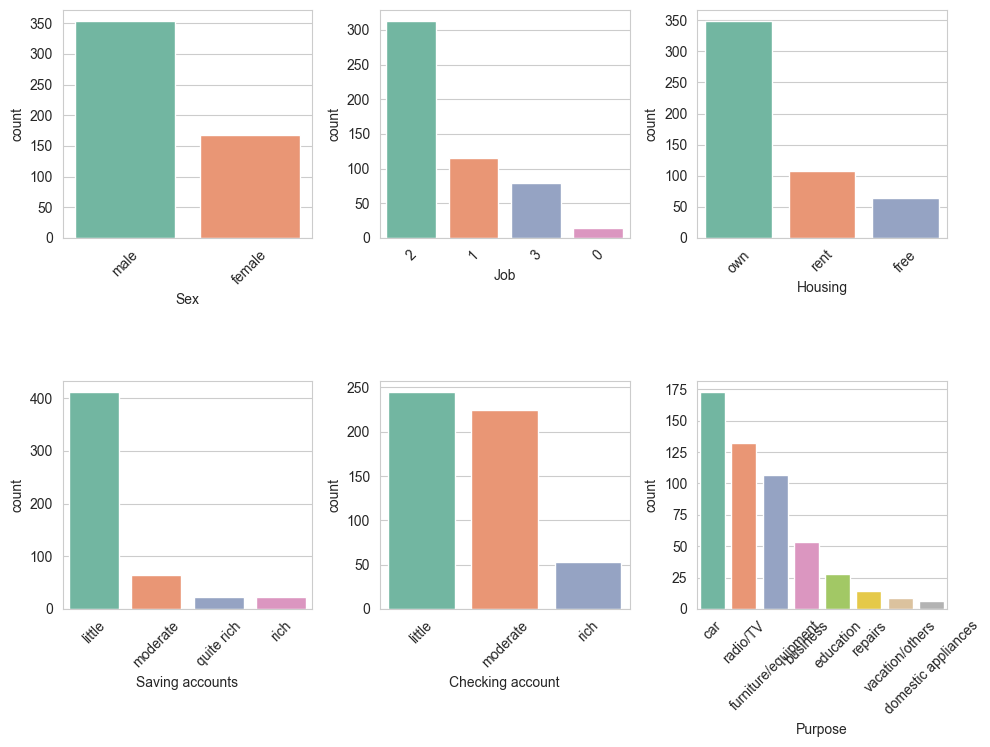

In [65]:
plt.figure(figsize=(10,10))
for i,col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

In [66]:
corr=df[['Age','Job','Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


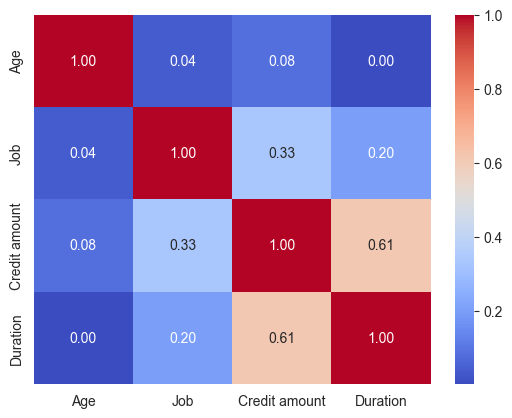

In [67]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()


<Axes: xlabel='Job'>

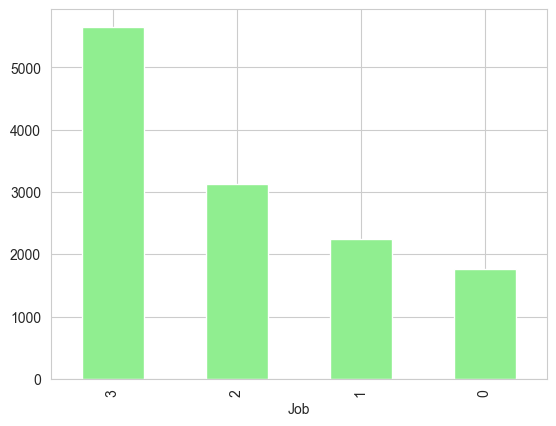

In [68]:
df.groupby('Job')['Credit amount'].mean().sort_values(ascending=False).plot(kind='bar',color='lightgreen')

<Axes: xlabel='Sex'>

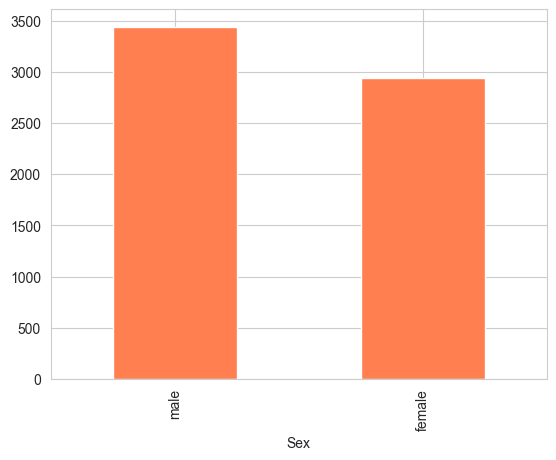

In [69]:
df.groupby('Sex')['Credit amount'].mean().sort_values(ascending=False).plot(kind='bar',color='coral')

In [70]:
df.groupby('Risk')[['Age','Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


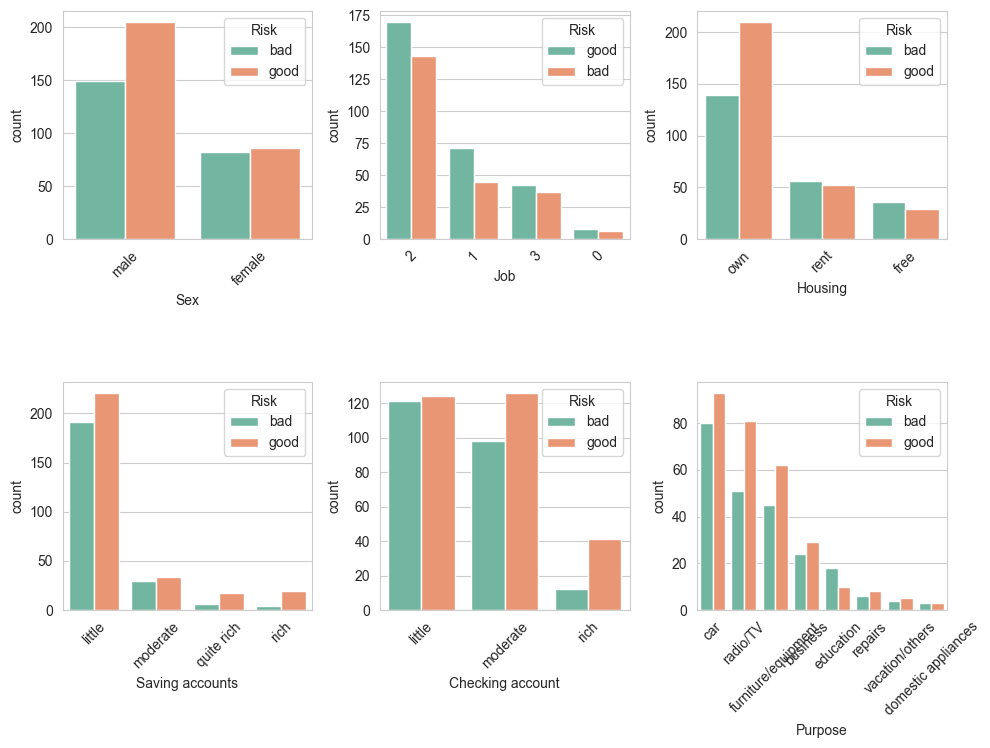

In [71]:
plt.figure(figsize=(10,10))
for i,col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue='Risk',palette='Set2',order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

In [72]:
features=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Credit amount', 'Duration']
target='Risk'

In [73]:
df_model=df[features+[target]]
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [74]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [75]:
cat=df_model.select_dtypes(include='object').columns.drop('Risk')
cat

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [76]:
for col in cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    joblib.dump(le, f'{col}_encoder.pkl')
    

C:\Users\janaj\AppData\Local\Temp\ipykernel_744\554464645.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = le.fit_transform(df_model[col])
C:\Users\janaj\AppData\Local\Temp\ipykernel_744\554464645.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = le.fit_transform(df_model[col])
C:\Users\janaj\AppData\Local\Temp\ipykernel_744\554464645.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [77]:
le_target=LabelEncoder()
df_model[target]=le_target.fit_transform(df_model[target])
joblib.dump(le_target,'target_encoder.pkl')

C:\Users\janaj\AppData\Local\Temp\ipykernel_744\1294191817.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[target]=le_target.fit_transform(df_model[target])


['target_encoder.pkl']

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
x=df_model.drop(columns=target)
x.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30


In [80]:
y=df_model[target]
y.head()

0    0
1    1
2    0
3    1
4    0
Name: Risk, dtype: int64

In [81]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train.shape,x_test.shape

((417, 8), (105, 8))

In [82]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}
0.6929718875502007


In [83]:
grid.predict(x_test)

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1])

In [84]:
joblib.dump(grid,'xgb_model.pkl')

['xgb_model.pkl']

In [85]:
df['Checking account'].nunique()

3